Disease Prediction from Medical Data

1: Google Drive

In [ ]:
# Google Drive Mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# ZIP file path
zip_path = "/content/drive/MyDrive/Disease_Prediction/Heart_Disease/heart_disease.zip"

# Extract folder
extract_path = "/content/drive/MyDrive/Disease_Prediction/Heart_Disease"

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

✅ Dataset Extracted Successfully!


In [ ]:
import os

folder_path = "/content/drive/MyDrive/Disease_Prediction/Heart_Disease"

print(os.listdir(folder_path))

['heart_disease.zip', 'costs', 'Index', 'ask-detrano', 'cleveland.data', 'cleve.mod', 'bak', 'WARNING', 'long-beach-va.data', 'hungarian.data', 'new.data', 'heart-disease.names', 'processed.cleveland.data', 'processed.hungarian.data', 'reprocessed.hungarian.data', 'processed.va.data', 'processed.switzerland.data', 'switzerland.data']


2: Dataset Load

In [ ]:
# Dataset Load
import pandas as pd

# Column Names (UCI Documentation ke according)
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

# Dataset Path
path = "/content/drive/MyDrive/Disease_Prediction/Heart_Disease/processed.cleveland.data"

# Read Dataset
df = pd.read_csv(path, names=columns)

# First 5 Rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
# Dataset Shape
print("Shape:", df.shape)

# Column Names
print("\nColumns:")
print(df.columns)

# Dataset Information
print("\nInformation:")
df.info()

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (303, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB

Missin

3: Data Cleaning

In [ ]:
print("CA Column")
print(df["ca"].dtype)

print("\nTHAL Column")
print(df["thal"].dtype)

CA Column
object

THAL Column
object


In [ ]:
import numpy as np

df["ca"] = df["ca"].replace("?", np.nan)
df["thal"] = df["thal"].replace("?", np.nan)

In [ ]:
df["ca"] = pd.to_numeric(df["ca"], errors="coerce")
df["thal"] = pd.to_numeric(df["thal"], errors="coerce")

In [ ]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [ ]:
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
df.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


4: Basic EDA

In [ ]:
# Statistical Summary
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [ ]:
print(df["target"].value_counts())

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [ ]:
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


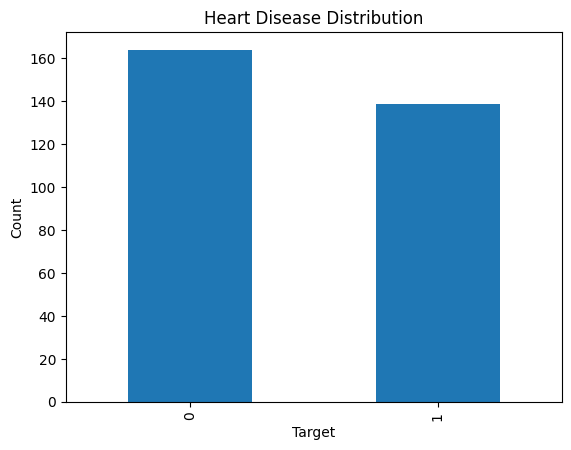

In [ ]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

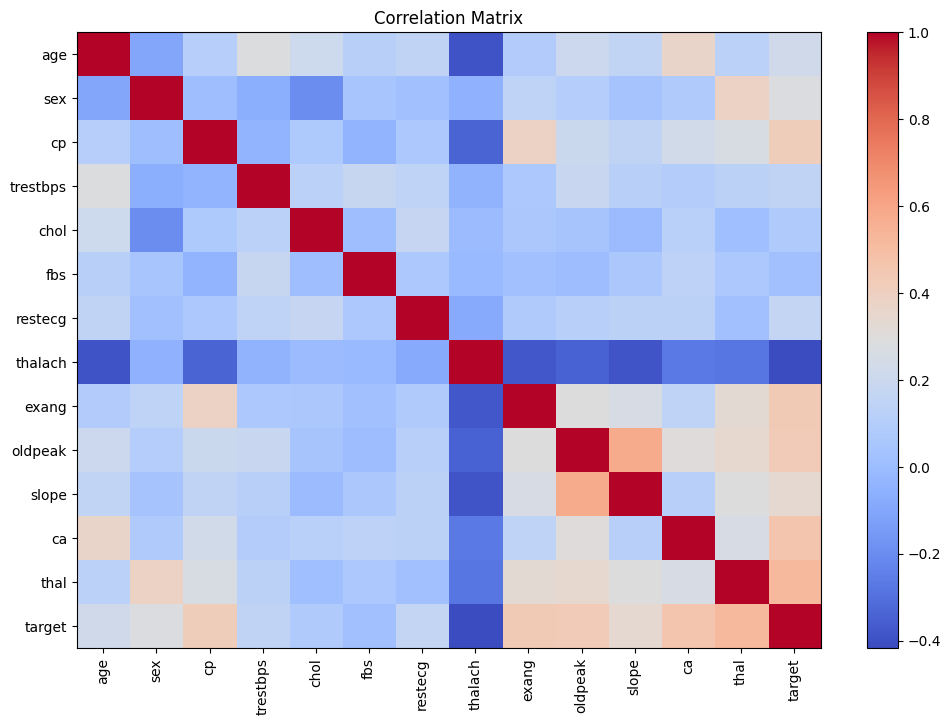

In [ ]:
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

5: Data Preprocessing

In [ ]:
# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (303, 13)
Target Shape : (303,)


In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (242, 13)
Testing Data : (61, 13)


In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [ ]:
# Verify Shapes
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (242, 13)
X_test : (61, 13)
y_train : (242,)
y_test : (61,)


6: Logistic Regression

In [ ]:
# Model Train
from sklearn.linear_model import LogisticRegression

# Create Model
lr = LogisticRegression(random_state=42)

# Train Model
lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!\n")

# Prediction
y_pred = lr.predict(X_test)

print(y_pred[:10])

Logistic Regression Model Trained Successfully!

[0 1 0 0 1 0 0 0 1 0]


In [ ]:
# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC AUC :", roc_auc)

Accuracy : 0.8688524590163934
Precision : 0.8125
Recall : 0.9285714285714286
F1 Score : 0.8666666666666667
ROC AUC : 0.8733766233766233


In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[27  6]
 [ 2 26]]


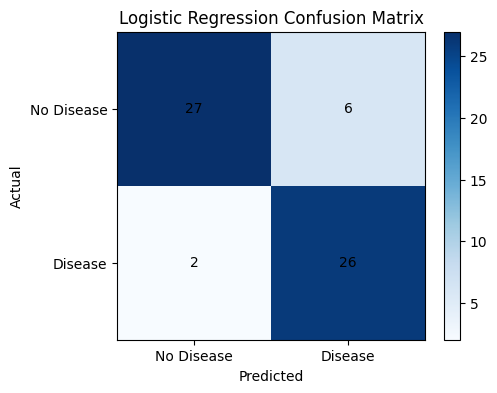

In [ ]:
# Confusion Matrix Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0,1], ["No Disease","Disease"])
plt.yticks([0,1], ["No Disease","Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="black")

plt.show()

7: Support Vector Machine (SVM)

In [ ]:
# Train SVM
from sklearn.svm import SVC

# Create Model
svm = SVC(kernel="rbf", probability=True, random_state=42)

# Train Model
svm.fit(X_train, y_train)

print("SVM Model Trained Successfully!")

# Prediction

y_pred_svm = svm.predict(X_test)

SVM Model Trained Successfully!


In [ ]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision :", precision_score(y_test, y_pred_svm))
print("Recall :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC AUC :", roc_auc_score(y_test, y_pred_svm))

Accuracy : 0.8524590163934426
Precision : 0.8064516129032258
Recall : 0.8928571428571429
F1 Score : 0.847457627118644
ROC AUC : 0.8555194805194805


In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



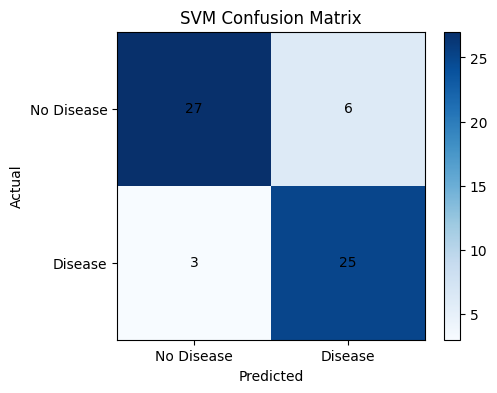

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0,1], ["No Disease","Disease"])
plt.yticks([0,1], ["No Disease","Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.show()

8: Random Forest

In [ ]:
# Train Model
from sklearn.ensemble import RandomForestClassifier

# Create Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

# Prediction

y_pred_rf = rf.predict(X_test)

Random Forest Model Trained Successfully!


In [ ]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC :", roc_auc_score(y_test, y_pred_rf))

Accuracy : 0.8852459016393442
Precision : 0.8181818181818182
Recall : 0.9642857142857143
F1 Score : 0.8852459016393442
ROC AUC : 0.8912337662337663


In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



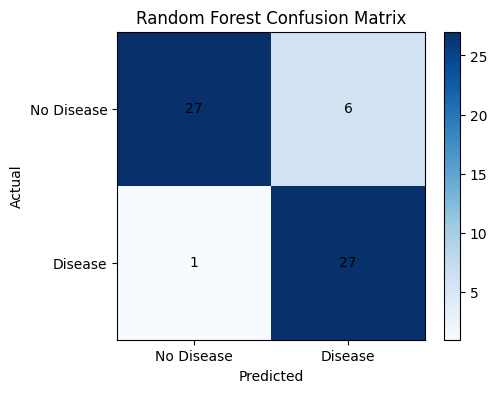

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0,1], ["No Disease","Disease"])
plt.yticks([0,1], ["No Disease","Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.show()

9: XGBoost

In [ ]:
# Install XGBoost
!pip install xgboost

In [ ]:
# Train XGBoost Model
from xgboost import XGBClassifier

# Create Model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train Model
xgb.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

# Prediction
y_pred_xgb = xgb.predict(X_test)

XGBoost Model Trained Successfully!


In [ ]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision :", precision_score(y_test, y_pred_xgb))
print("Recall :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC :", roc_auc_score(y_test, y_pred_xgb))

Accuracy : 0.8524590163934426
Precision : 0.7878787878787878
Recall : 0.9285714285714286
F1 Score : 0.8524590163934426
ROC AUC : 0.8582251082251082


In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



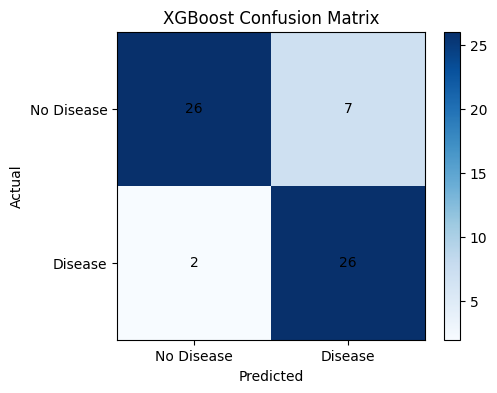

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0,1], ["No Disease","Disease"])
plt.yticks([0,1], ["No Disease","Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.show()

10: ROC Curve

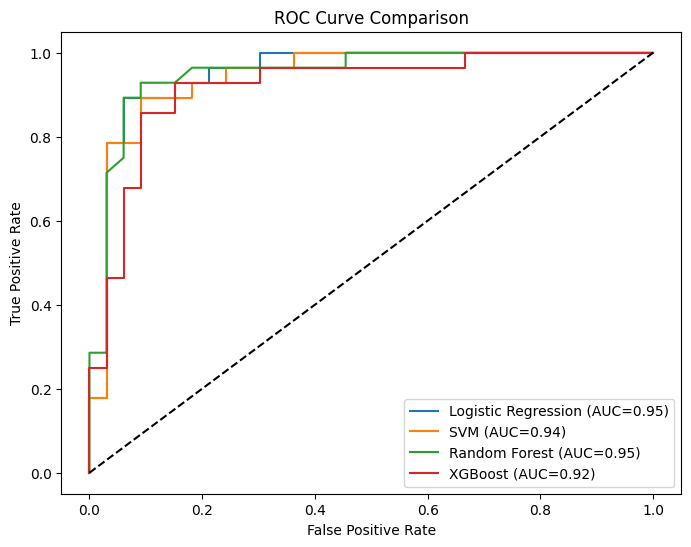

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability Predictions
lr_prob = lr.predict_proba(X_test)[:,1]
svm_prob = svm.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]

# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.2f})')

plt.plot(svm_fpr, svm_tpr,
         label=f'SVM (AUC={roc_auc_score(y_test, svm_prob):.2f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC={roc_auc_score(y_test, rf_prob):.2f})')

plt.plot(xgb_fpr, xgb_tpr,
         label=f'XGBoost (AUC={roc_auc_score(y_test, xgb_prob):.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

11. Model Comparison Graph

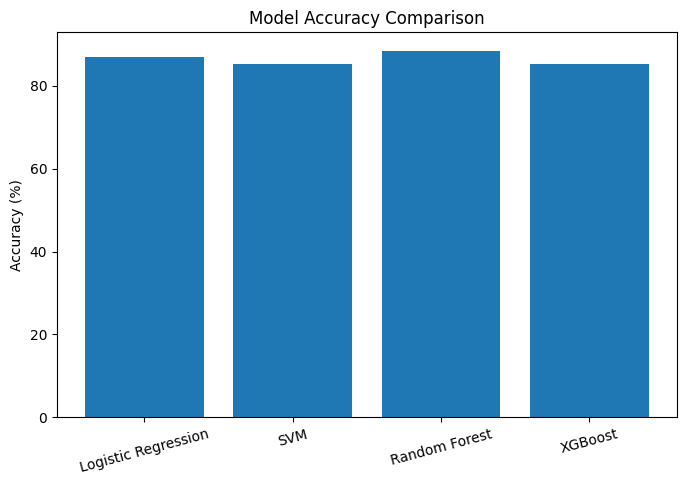

In [ ]:
# Model Comparsion Graph
import matplotlib.pyplot as plt

models = ["Logistic Regression",
          "SVM",
          "Random Forest",
          "XGBoost"]

accuracy = [
    86.89,
    85.25,
    88.52,
    85.25
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

12: Feature Importance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

     Feature  Importance
7    thalach    0.135404
2         cp    0.127163
12      thal    0.122940
11        ca    0.100811
0        age    0.091327
9    oldpeak    0.089358
4       chol    0.088681
3   trestbps    0.080716
8      exang    0.050730
10     slope    0.046626
1        sex    0.035947
6    restecg    0.018389
5        fbs    0.011908


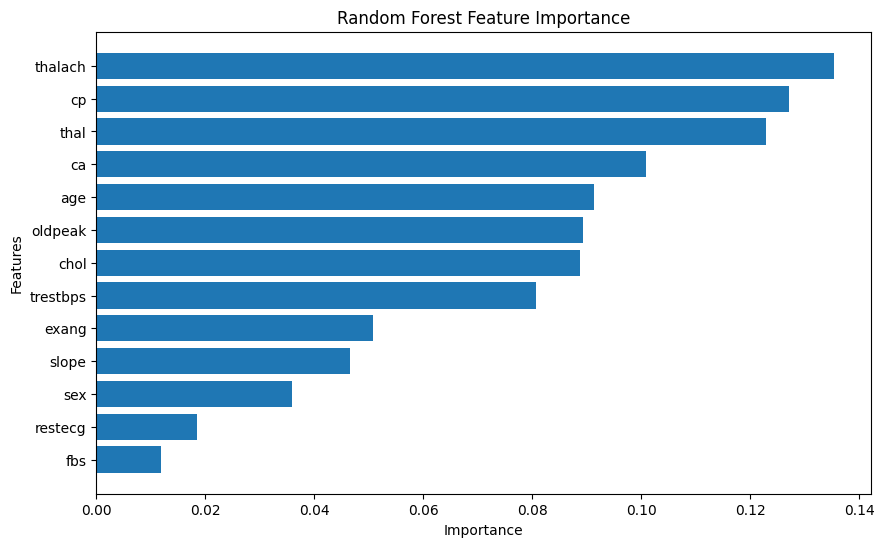

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

13: Save Best Model

In [ ]:

import joblib

loaded_model = joblib.load(
    "/content/drive/MyDrive/Disease_Prediction/heart_disease_model.pkl"
)

loaded_scaler = joblib.load(
    "/content/drive/MyDrive/Disease_Prediction/scaler.pkl"
)

print("Model and Scaler Loaded Successfully!")

Model and Scaler Loaded Successfully!


14: Predict New Patient

In [ ]:

import pandas as pd

new_patient = pd.DataFrame([{
    "age": 55,
    "sex": 1,
    "cp": 2,
    "trestbps": 130,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.5,
    "slope": 2,
    "ca": 0,
    "thal": 3
}])

# Scale the patient data
new_patient_scaled = loaded_scaler.transform(new_patient)

# Prediction
prediction = loaded_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("🔴 Heart Disease Detected")
else:
    print("🟢 No Heart Disease")

🟢 No Heart Disease


Final Results:

In [ ]:

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.868852,
        0.852459,
        0.885246,
        0.852459
    ],
    "Precision": [
        0.812500,
        0.806452,
        0.818182,
        0.787879
    ],
    "Recall": [
        0.928571,
        0.892857,
        0.964286,
        0.928571
    ],
    "F1 Score": [
        0.866667,
        0.847458,
        0.885246,
        0.852459
    ],
    "ROC-AUC": [
        0.873377,
        0.855519,
        0.891234,
        0.858225
    ]
})

# Convert values to percentage
results_percentage = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]:
    results_percentage[column] = (
        results_percentage[column] * 100
    ).round(2)

results_percentage

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,86.89,81.25,92.86,86.67,87.34
1,SVM,85.25,80.65,89.29,84.75,85.55
2,Random Forest,88.52,81.82,96.43,88.52,89.12
3,XGBoost,85.25,78.79,92.86,85.25,85.82
